In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [12]:
# Load data
dxy = pd.read_csv(DATA_DIR / "USD_Index.csv", parse_dates=["observation_date"], index_col="observation_date")
tsy = pd.read_csv(DATA_DIR / "Treasury_Yield.csv", parse_dates=["observation_date"], index_col="observation_date")

# Merge
df = dxy.join(tsy, how="inner")
df.columns = ["DXY", "Yield_10Y"]
df = df.dropna()

print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Observations: {len(df)}")
df.tail()

Date range: 2010-01-04 to 2026-04-17
Observations: 4045


,DXY,Yield_10Y
observation_date,,
2026-04-13,118.9916,4.30
2026-04-14,118.3581,4.26
2026-04-15,118.3623,4.29
2026-04-16,118.3616,4.32
2026-04-17,118.0795,4.26


In [13]:
# Key tariff event dates
events = {
    "2025-01-20": "Inauguration",
    "2025-04-02": "Liberation Day",
    "2025-04-09": "90-day pause",
}

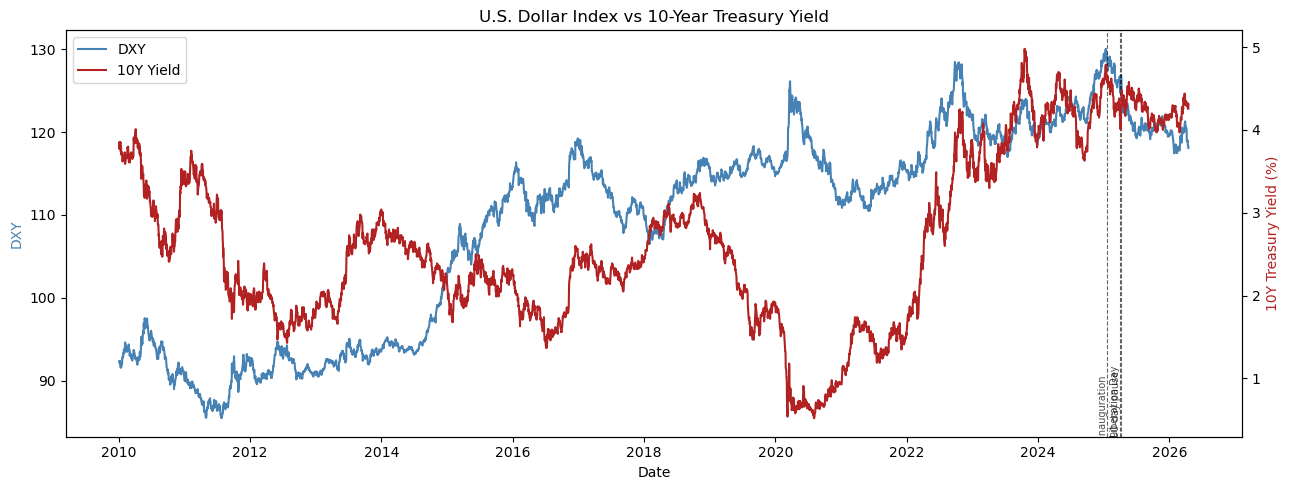

In [14]:
# Plot 1: DXY and 10Y yield over time (dual axis)
fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax1.plot(df.index, df["DXY"], color="steelblue", linewidth=1.5, label="DXY")
ax2.plot(df.index, df["Yield_10Y"], color="firebrick", linewidth=1.5, label="10Y Yield")

for date, label in events.items():
    ax1.axvline(pd.to_datetime(date), color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[0], label, rotation=90,
             fontsize=7, va="bottom", ha="right", alpha=0.7)

ax1.set_ylabel("DXY", color="steelblue")
ax2.set_ylabel("10Y Treasury Yield (%)", color="firebrick")
ax1.set_xlabel("Date")
ax1.set_title("U.S. Dollar Index vs 10-Year Treasury Yield")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_dxy_yield_over_time.png", dpi=150)
plt.show()

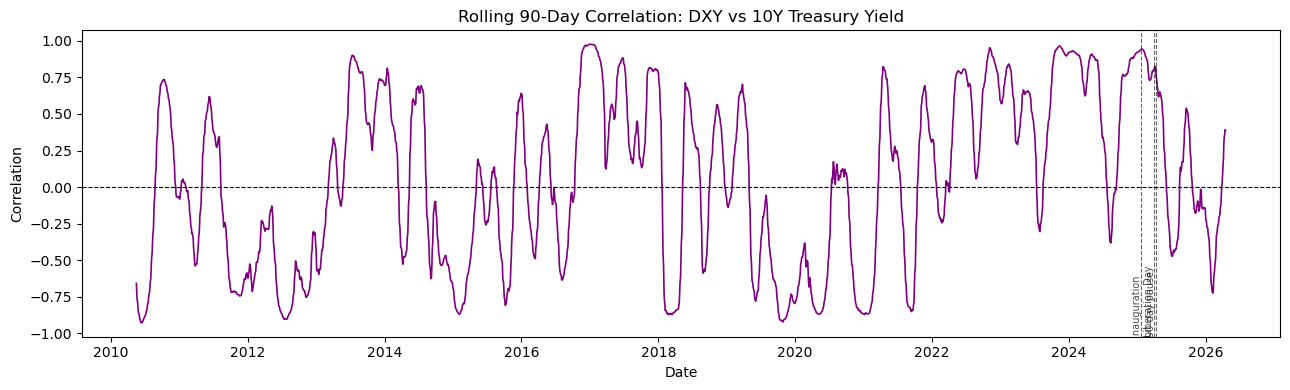

In [15]:
# Plot 2: Rolling 90-day correlation between DXY and 10Y yield
df["rolling_corr"] = df["DXY"].rolling(90).corr(df["Yield_10Y"])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df["rolling_corr"], color="purple", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

for date, label in events.items():
    ax.axvline(pd.to_datetime(date), color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[0], label, rotation=90,
            fontsize=7, va="bottom", ha="right", alpha=0.7)

ax.set_ylabel("Correlation")
ax.set_xlabel("Date")
ax.set_title("Rolling 90-Day Correlation: DXY vs 10Y Treasury Yield")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_rolling_correlation.png", dpi=150)
plt.show()

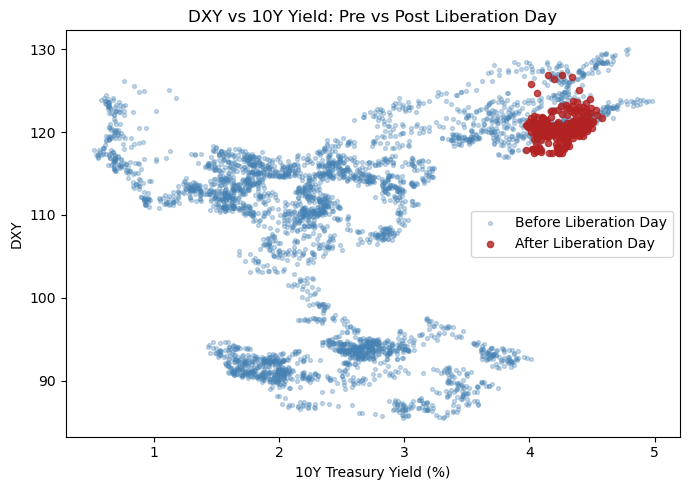

In [16]:
# Plot 3: Scatter plot — pre vs post Liberation Day
cutoff = pd.to_datetime("2025-04-02")
pre  = df[df.index < cutoff]
post = df[df.index >= cutoff]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pre["Yield_10Y"], pre["DXY"], alpha=0.3, s=8, color="steelblue", label="Before Liberation Day")
ax.scatter(post["Yield_10Y"], post["DXY"], alpha=0.8, s=20, color="firebrick", label="After Liberation Day")

ax.set_xlabel("10Y Treasury Yield (%)")
ax.set_ylabel("DXY")
ax.set_title("DXY vs 10Y Yield: Pre vs Post Liberation Day")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_scatter_pre_post.png", dpi=150)
plt.show()

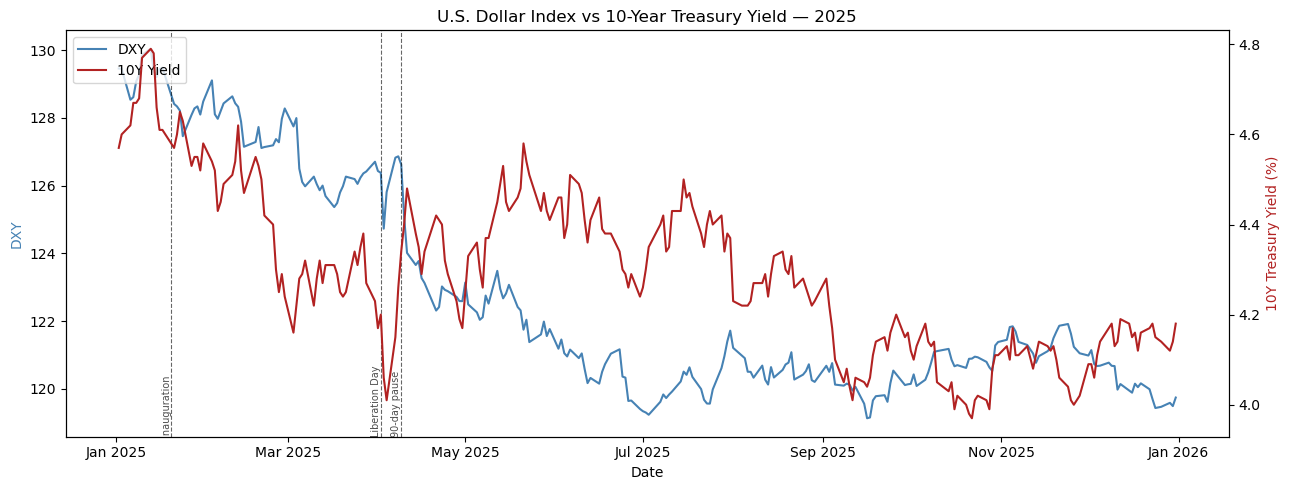

In [17]:
# Plot 4: DXY and 10Y yield — 2025 only (dual axis)
df_2025 = df[df.index.year == 2025]

fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax1.plot(df_2025.index, df_2025["DXY"], color="steelblue", linewidth=1.5, label="DXY")
ax2.plot(df_2025.index, df_2025["Yield_10Y"], color="firebrick", linewidth=1.5, label="10Y Yield")

for date, label in events.items():
    dt = pd.to_datetime(date)
    if dt.year == 2025:
        ax1.axvline(dt, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
        ax1.text(dt, ax1.get_ylim()[0], label, rotation=90,
                 fontsize=7, va="bottom", ha="right", alpha=0.7)

ax1.set_ylabel("DXY", color="steelblue")
ax2.set_ylabel("10Y Treasury Yield (%)", color="firebrick")
ax1.set_xlabel("Date")
ax1.set_title("U.S. Dollar Index vs 10-Year Treasury Yield — 2025")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_dxy_yield_2025.png", dpi=150)
plt.show()

In [18]:
# Correlation summary
corr_full = df["DXY"].corr(df["Yield_10Y"])
corr_pre  = pre["DXY"].corr(pre["Yield_10Y"])
corr_post = post["DXY"].corr(post["Yield_10Y"])

print("Correlation — DXY vs 10Y Yield")
print(f"  Full sample          : {corr_full:.3f}")
print(f"  Pre  (< Apr 2 2025)  : {corr_pre:.3f}")
print(f"  Post (>= Apr 2 2025) : {corr_post:.3f}")

Correlation — DXY vs 10Y Yield
  Full sample          : 0.267
  Pre  (< Apr 2 2025)  : 0.185
  Post (>= Apr 2 2025) : 0.236


In [19]:
# Engle-Granger cointegration test
from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(df["DXY"], df["Yield_10Y"])
print("Engle-Granger Cointegration Test")
print(f"  Test statistic : {score:.4f}")
print(f"  p-value        : {pvalue:.4f}")
if pvalue < 0.05:
    print("  Result: Series are cointegrated (long-run relationship exists)")
else:
    print("  Result: No cointegration found")

Engle-Granger Cointegration Test
  Test statistic : -1.6217
  p-value        : 0.7116
  Result: No cointegration found


In [20]:
# Save combined dataset
df.to_csv(DATA_DIR / "combined.csv")
print("Combined data saved to data/combined.csv")

Combined data saved to data/combined.csv
